In [1]:
import sys, os
from pathlib import Path

os.environ['USE_CUPY'] = 'false'

# Ensure project import path
PROJECT_ROOT = Path('/global/home/hpc5656/SLAM')
sys.path.append(str(PROJECT_ROOT))
# Set working directory so relative paths (e.g., src/config/*.yaml) resolve
os.chdir(str(PROJECT_ROOT))
print('CWD:', Path.cwd())

%matplotlib inline

CWD: /global/home/hpc5656/SLAM


In [2]:
import numpy as np
from src.belief_quantized.belief_mdp_n import BeliefMDP_n_SLAM
from src.classes.model import DoubleIntegratorModel, LIDAR
from src.classes.mapping import LidarGridMapVec
from src.utils.map import load_obstacles_config
import warnings
import matplotlib.pyplot as plt

# Suppress CuPy experimental FutureWarnings for multivariate_normal
# These warnings are harmless and clutter the output
warnings.filterwarnings('ignore', category=FutureWarning, module='cupy.random')

print(f"✓ All imports successful")

# Output dir
OUTDIR = PROJECT_ROOT / 'notebooks' / 'slam' / 'outputs' / 'qmat_visuals'
OUTDIR.mkdir(parents=True, exist_ok=True)
print('Figures will be saved to:', OUTDIR)

ℹ Using scipy.spatial.KDTree (NumPy backend)
✓ All imports successful
Figures will be saved to: /global/home/hpc5656/SLAM/notebooks/slam/outputs/qmat_visuals


In [3]:
def build_mdp(n=5, obs_n=3, dt=1.0, max_a=5.0, sigma_v=1.0):
    all_obstacles, area = load_obstacles_config(environment='toy2')
    model = DoubleIntegratorModel(p_x=5.0, p_y=5.0, v_x=0.0, v_y=0.0, dt=dt, max_a=max_a)
    sensor = LIDAR(fov=360, r_max=10.0, B=8)
    grid_map = LidarGridMapVec(x_min=area[0], x_max=area[1], y_min=area[2], y_max=area[3], quantization_level=n)
    mdp = BeliefMDP_n_SLAM(
        n=n, 
        motion_model=model, 
        measurement_model=sensor, 
        obstacles=all_obstacles, 
        _map=grid_map,
        sigma_v=sigma_v
    )
    # Configure observation quantization
    mdp.configure_observation_quantization(obs_n=obs_n)
    return mdp


def verify_stochastic_properties(Q_n, tolerance=1e-6):
    """
    Verify that Q_n satisfies stochastic matrix properties:
    1. Non-negativity: Q_n >= 0
    2. Normalization: For each (state, map), sum over observations = 1
    """
    m_y, m_n, len_M = Q_n.shape
    
    # Check 1: Non-negativity
    min_val = np.min(Q_n)
    has_negatives = min_val < -tolerance
    
    # Check 2: Row sums (for each state-map pair, sum over observations)
    row_sums = np.sum(Q_n, axis=0)  # (m_n, len_M)
    expected_sum = 1.0
    max_deviation = np.max(np.abs(row_sums - expected_sum))
    mean_sum = np.mean(row_sums)
    
    results = {
        'non_negative': not has_negatives,
        'min_value': float(min_val),
        'row_sums_valid': max_deviation < tolerance,
        'max_row_sum_deviation': float(max_deviation),
        'mean_row_sum': float(mean_sum),
        'row_sums': row_sums
    }
    
    return results


def plot_observation_distribution(mdp: BeliefMDP_n_SLAM, i_state: int, j_map: int, title: str):
    """
    Plot the observation distribution Q_n[:, i_state, j_map] for a given state-map pair.
    """
    Q_n = mdp.Q_n
    m_y = Q_n.shape[0]
    
    # Get observation distribution for this state-map pair
    obs_dist = Q_n[:, i_state, j_map]  # (m_y,)
    
    # Get state and map info
    x_state = mdp.SQ.X_n[i_state]
    map_array = mdp.all_maps_3d[j_map] if mdp.all_maps_3d is not None else None
    
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: Histogram of observation probabilities
    axs[0].bar(range(m_y), obs_dist, alpha=0.7, color='steelblue')
    axs[0].set_xlabel('Observation Index')
    axs[0].set_ylabel('Probability')
    axs[0].set_title(f'Q_n[:, state={i_state}, map={j_map}]\n' +
                    f'State: pos=[{x_state[0]:.2f}, {x_state[1]:.2f}]')
    axs[0].grid(True, alpha=0.3)
    
    # Check if distribution sums to 1
    total_prob = np.sum(obs_dist)
    axs[0].axhline(y=1.0, color='r', linestyle='--', linewidth=2, label=f'Sum = {total_prob:.6f}')
    axs[0].legend()
    
    # Right: Top-K observations (if many observations)
    if m_y > 20:
        top_k = min(20, m_y)
        top_indices = np.argsort(obs_dist)[-top_k:][::-1]
        top_probs = obs_dist[top_indices]
        
        axs[1].barh(range(top_k), top_probs, alpha=0.7, color='coral')
        axs[1].set_yticks(range(top_k))
        axs[1].set_yticklabels([f'obs_{idx}' for idx in top_indices])
        axs[1].set_xlabel('Probability')
        axs[1].set_title(f'Top {top_k} Most Likely Observations')
        axs[1].grid(True, alpha=0.3, axis='x')
    else:
        # Show all observations
        axs[1].bar(range(m_y), obs_dist, alpha=0.7, color='coral')
        axs[1].set_xlabel('Observation Index')
        axs[1].set_ylabel('Probability')
        axs[1].set_title('All Observations')
        axs[1].grid(True, alpha=0.3)
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    fig.tight_layout()
    
    plt.show()
    
    # Save to disk
    outfile = OUTDIR / f"qmat_visual_{title.replace(' ', '_')}.png"
    fig.savefig(outfile, dpi=150, bbox_inches='tight')
    print('Saved figure to', outfile)

In [9]:
def visualize_measurements(mdp: BeliefMDP_n_SLAM, i_state: int, j_map: int, title: str, n_top: int = 3, n_bottom: int = 3):
    """
    Visualize the top n_top and bottom n_bottom probability measurements as LIDAR rays.
    
    Args:
        mdp: BeliefMDP_n_SLAM instance
        i_state: State index
        j_map: Map index
        title: Title for the figure
        n_top: Number of top probability measurements to visualize
        n_bottom: Number of bottom probability measurements to visualize
    """
    from src.utils.map import load_obstacles_config
    
    Q_n = mdp.Q_n
    obs_dist = Q_n[:, i_state, j_map]  # (m_y,)
    
    # Get top and bottom observation indices
    top_indices = np.argsort(obs_dist)[-n_top:][::-1]  # Highest probabilities
    bottom_indices = np.argsort(obs_dist)[:n_bottom]  # Lowest probabilities
    
    # Get state and map info
    x_state = mdp.SQ.X_n[i_state]  # (x, y, vx, vy) or (x, y)
    robot_pos = x_state[:2]  # Extract position
    
    # Get map
    map_array = mdp.all_maps_3d[j_map] if mdp.all_maps_3d is not None else None
    
    # Get sensor angles
    angles = np.asarray(mdp.sensor.angles)  # (B,)
    B = len(angles)
    
    # Get observation measurements (distances per beam)
    Y_n = mdp.Y_n  # (m_y, B) - each row is a quantized observation
    
    # Load obstacles for visualization
    all_obstacles, area = load_obstacles_config(environment='toy2')
    
    # Build obstacle segments from map
    if map_array is not None:
        segments = mdp.sensor.get_obstacles_from_map(map_array, mdp.map)
    else:
        # Fallback: use actual obstacles
        all_obstacle_segments = []
        for obs in all_obstacles:
            all_obstacle_segments += list(obs._Obstacle__get_points(obs.centroid))
        segments = all_obstacle_segments
    
    # Create figure with subplots: top measurements on top row, bottom on bottom row
    n_cols = max(n_top, n_bottom)
    fig, axs = plt.subplots(2, n_cols, figsize=(5*n_cols, 10))
    if n_cols == 1:
        axs = axs.reshape(2, 1)
    
    # Plot top measurements
    for idx, obs_idx in enumerate(top_indices):
        ax = axs[0, idx]
        
        # Get measurement distances for this observation
        measurement_distances = Y_n[obs_idx]  # (B,)
        prob = obs_dist[obs_idx]
        
        # Convert to endpoints
        endpoints = np.vstack([
            measurement_distances * np.cos(angles),
            measurement_distances * np.sin(angles)
        ]).T + robot_pos
        
        # Plot map background
        if map_array is not None:
            H, W = map_array.shape
            x_min, y_min = mdp.map.left_lower
            x_max, y_max = mdp.map.right_upper
            extent = [x_min, x_max, y_min, y_max]
            
            # Create colormap: 0=free (white), 0.5=unknown (grey), 1=obstacle (red)
            from matplotlib.colors import ListedColormap, BoundaryNorm
            grid_cmap = ListedColormap(['white', 'grey', 'red'])
            grid_bounds = [0.0, 0.25, 0.75, 1.0]
            grid_norm = BoundaryNorm(grid_bounds, grid_cmap.N)
            
            ax.imshow(map_array, cmap=grid_cmap, norm=grid_norm, 
                     extent=extent, origin='lower', alpha=0.7, zorder=0)
        
        # Plot LIDAR rays
        for i in range(B):
            ax.plot([robot_pos[0], endpoints[i, 0]], 
                   [robot_pos[1], endpoints[i, 1]],
                   c='blue', alpha=0.3, linewidth=0.5, zorder=1)
            
            # Mark hits (distances < r_max)
            if measurement_distances[i] < mdp.sensor.r_max:
                ax.scatter(endpoints[i, 0], endpoints[i, 1],
                          marker='o', c='red', s=20, zorder=2, edgecolor='none')
        
        # Plot robot position
        ax.scatter([robot_pos[0]], [robot_pos[1]], 
                  marker='*', c='black', s=200, zorder=3, edgecolor='white', linewidth=1)
        
        ax.set_xlim(area[0], area[1])
        ax.set_ylim(area[2], area[3])
        ax.set_aspect('equal', adjustable='box')
        ax.set_title(f'Top {idx+1}: P={prob:.2e}', fontsize=10)
        ax.grid(True, alpha=0.3)
    
    # Plot bottom measurements
    for idx, obs_idx in enumerate(bottom_indices):
        ax = axs[1, idx]
        
        # Get measurement distances for this observation
        measurement_distances = Y_n[obs_idx]  # (B,)
        prob = obs_dist[obs_idx]
        
        # Convert to endpoints
        endpoints = np.vstack([
            measurement_distances * np.cos(angles),
            measurement_distances * np.sin(angles)
        ]).T + robot_pos
        
        # Plot map background
        if map_array is not None:
            H, W = map_array.shape
            x_min, y_min = mdp.map.left_lower
            x_max, y_max = mdp.map.right_upper
            extent = [x_min, x_max, y_min, y_max]
            
            from matplotlib.colors import ListedColormap, BoundaryNorm
            grid_cmap = ListedColormap(['white', 'grey', 'red'])
            grid_bounds = [0.0, 0.25, 0.75, 1.0]
            grid_norm = BoundaryNorm(grid_bounds, grid_cmap.N)
            
            ax.imshow(map_array, cmap=grid_cmap, norm=grid_norm,
                     extent=extent, origin='lower', alpha=0.7, zorder=0)
        
        # Plot LIDAR rays
        for i in range(B):
            ax.plot([robot_pos[0], endpoints[i, 0]], 
                   [robot_pos[1], endpoints[i, 1]],
                   c='blue', alpha=0.3, linewidth=0.5, zorder=1)
            
            # Mark hits (distances < r_max)
            if measurement_distances[i] < mdp.sensor.r_max:
                ax.scatter(endpoints[i, 0], endpoints[i, 1],
                          marker='o', c='red', s=20, zorder=2, edgecolor='none')
        
        # Plot robot position
        ax.scatter([robot_pos[0]], [robot_pos[1]], 
                  marker='*', c='black', s=200, zorder=3, edgecolor='white', linewidth=1)
        
        ax.set_xlim(area[0], area[1])
        ax.set_ylim(area[2], area[3])
        ax.set_aspect('equal', adjustable='box')
        ax.set_title(f'Bottom {idx+1}: P={prob:.2e}', fontsize=10)
        ax.grid(True, alpha=0.3)
    
    fig.suptitle(f'{title}\nState: pos=[{robot_pos[0]:.2f}, {robot_pos[1]:.2f}]', 
                 fontsize=14, fontweight='bold')
    fig.tight_layout()
    
    plt.show()
    
    # Save to disk
    outfile = OUTDIR / f"measurements_{title.replace(' ', '_')}.png"
    fig.savefig(outfile, dpi=150, bbox_inches='tight')
    print('Saved figure to', outfile)

In [5]:
# Build or load MDP (this will compute and cache Q_n on first run)
mdp = build_mdp(n=3, obs_n=3, dt=1, max_a=2.0, sigma_v=1.0)
print('Q_n shape:', mdp.Q_n.shape)
print('Observation space size (m_y):', mdp.Q_n.shape[0])
print('State space size (m_n):', mdp.SQ.m_n)
print('Map space size (len_M):', mdp.len_M)
print(f'Observation quantization: obs_n={mdp.obs_n}')
print(f'Sensor: B={mdp.sensor.B} beams, r_max={mdp.sensor.r_max}')
print()

Loaded cached T_mat from /global/home/hpc5656/SLAM/cache/T_mat/T_mat_n3_map3x3_max2.0_c2818dab.npz
  Checking cache file: Q_n_n3_obs3_map3x3_B8_c18e598c.npz
  ✓ Cache metadata matches, loading Q_n
Loaded cached Q_n from /global/home/hpc5656/SLAM/cache/Q_n/Q_n_n3_obs3_map3x3_B8_c18e598c.npz
  Checking cache file: Q_n_n3_obs3_map3x3_B8_c18e598c.npz
  ✓ Cache metadata matches, loading Q_n
Loaded cached Q_n with obs_n=3 from /global/home/hpc5656/SLAM/cache/Q_n/Q_n_n3_obs3_map3x3_B8_c18e598c.npz
Q_n shape: (6561, 81, 512)
Observation space size (m_y): 6561
State space size (m_n): 81
Map space size (len_M): 512
Observation quantization: obs_n=3
Sensor: B=8 beams, r_max=10.0



In [6]:
# Verify stochastic matrix properties
print('='*70)
print('=== Verifying Q_n Stochastic Matrix Properties ===')
print('='*70)

results = verify_stochastic_properties(mdp.Q_n, tolerance=1e-6)

print(f"\n1. Non-negativity check:")
print(f"   ✓ All values >= 0: {results['non_negative']}")
print(f"   Minimum value: {results['min_value']:.6e}")

print(f"\n2. Normalization check (row sums):")
print(f"   ✓ Row sums ≈ 1.0: {results['row_sums_valid']}")
print(f"   Mean row sum: {results['mean_row_sum']:.6f}")
print(f"   Max deviation from 1.0: {results['max_row_sum_deviation']:.6e}")

# Check for any problematic rows
row_sums = results['row_sums']
problematic = np.where(np.abs(row_sums - 1.0) > 1e-4)[0]
if len(problematic) > 0:
    print(f"\n   ⚠ Found {len(problematic)} state-map pairs with row sum deviation > 1e-4")
    print(f"   First 10 problematic indices: {problematic[:10]}")
else:
    print(f"\n   ✓ All row sums are within tolerance")

print('\n' + '='*70)

=== Verifying Q_n Stochastic Matrix Properties ===



1. Non-negativity check:
   ✓ All values >= 0: True
   Minimum value: 2.198590e-85

2. Normalization check (row sums):
   ✓ Row sums ≈ 1.0: True
   Mean row sum: 1.000000
   Max deviation from 1.0: 3.108624e-14

   ✓ All row sums are within tolerance




=== Visualizing Observation Distributions ===



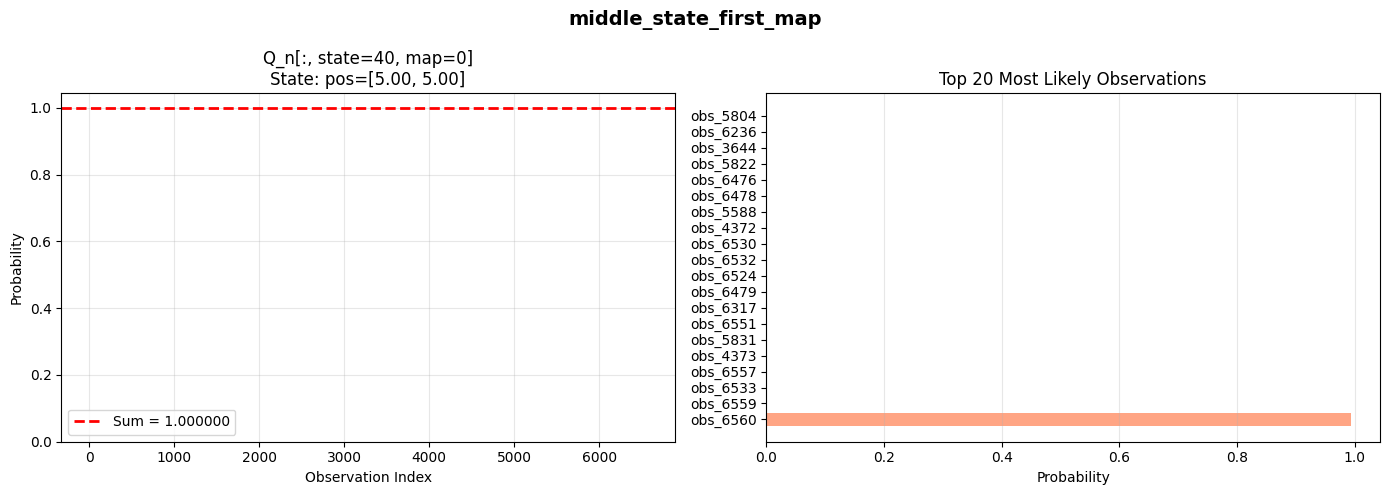

Saved figure to /global/home/hpc5656/SLAM/notebooks/slam/outputs/qmat_visuals/qmat_visual_middle_state_first_map.png


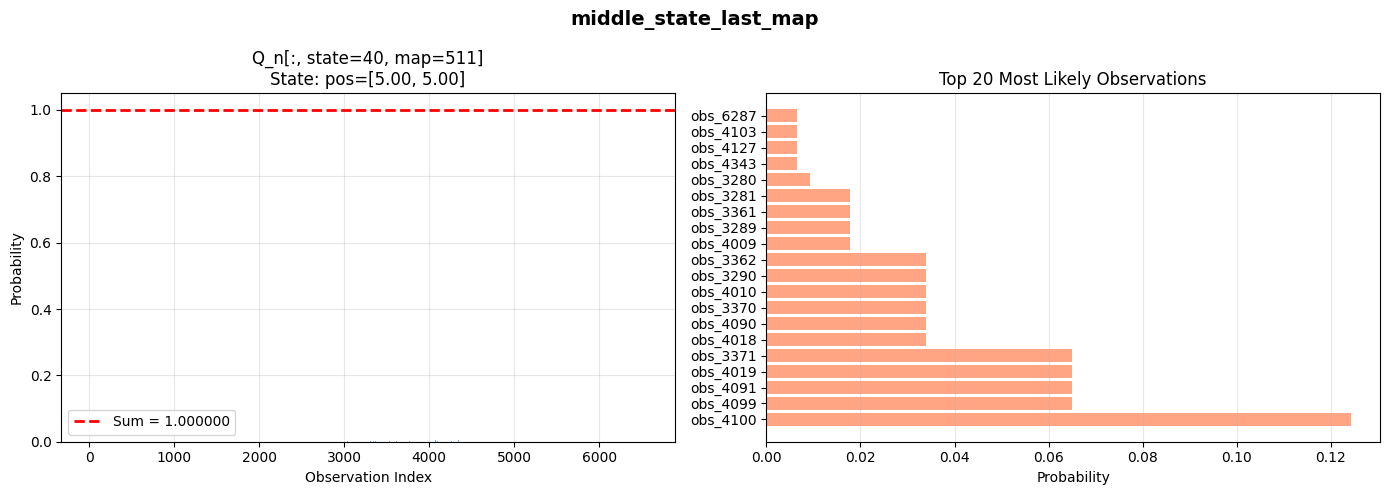

Saved figure to /global/home/hpc5656/SLAM/notebooks/slam/outputs/qmat_visuals/qmat_visual_middle_state_last_map.png


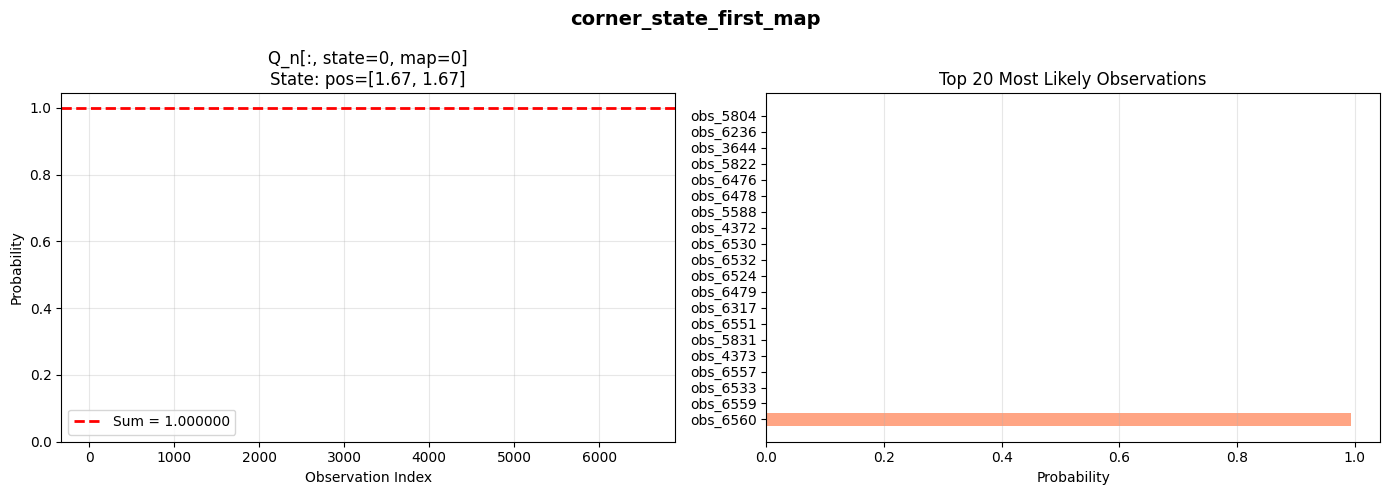

Saved figure to /global/home/hpc5656/SLAM/notebooks/slam/outputs/qmat_visuals/qmat_visual_corner_state_first_map.png


In [7]:
# Visualize observation distributions for different state-map pairs
print('\n=== Visualizing Observation Distributions ===\n')

# Case 1: Middle state, first map
i_state = mdp.SQ.m_n // 2
j_map = 0
plot_observation_distribution(mdp, i_state, j_map, title='middle_state_first_map')

# Case 2: Middle state, last map (if exists)
if mdp.len_M > 1:
    j_map = mdp.len_M - 1
    plot_observation_distribution(mdp, i_state, j_map, title='middle_state_last_map')

# Case 3: Corner state, first map
if mdp.SQ.m_n > 1:
    i_state = 0
    j_map = 0
    plot_observation_distribution(mdp, i_state, j_map, title='corner_state_first_map')


=== Visualizing Top and Bottom Probability Measurements ===



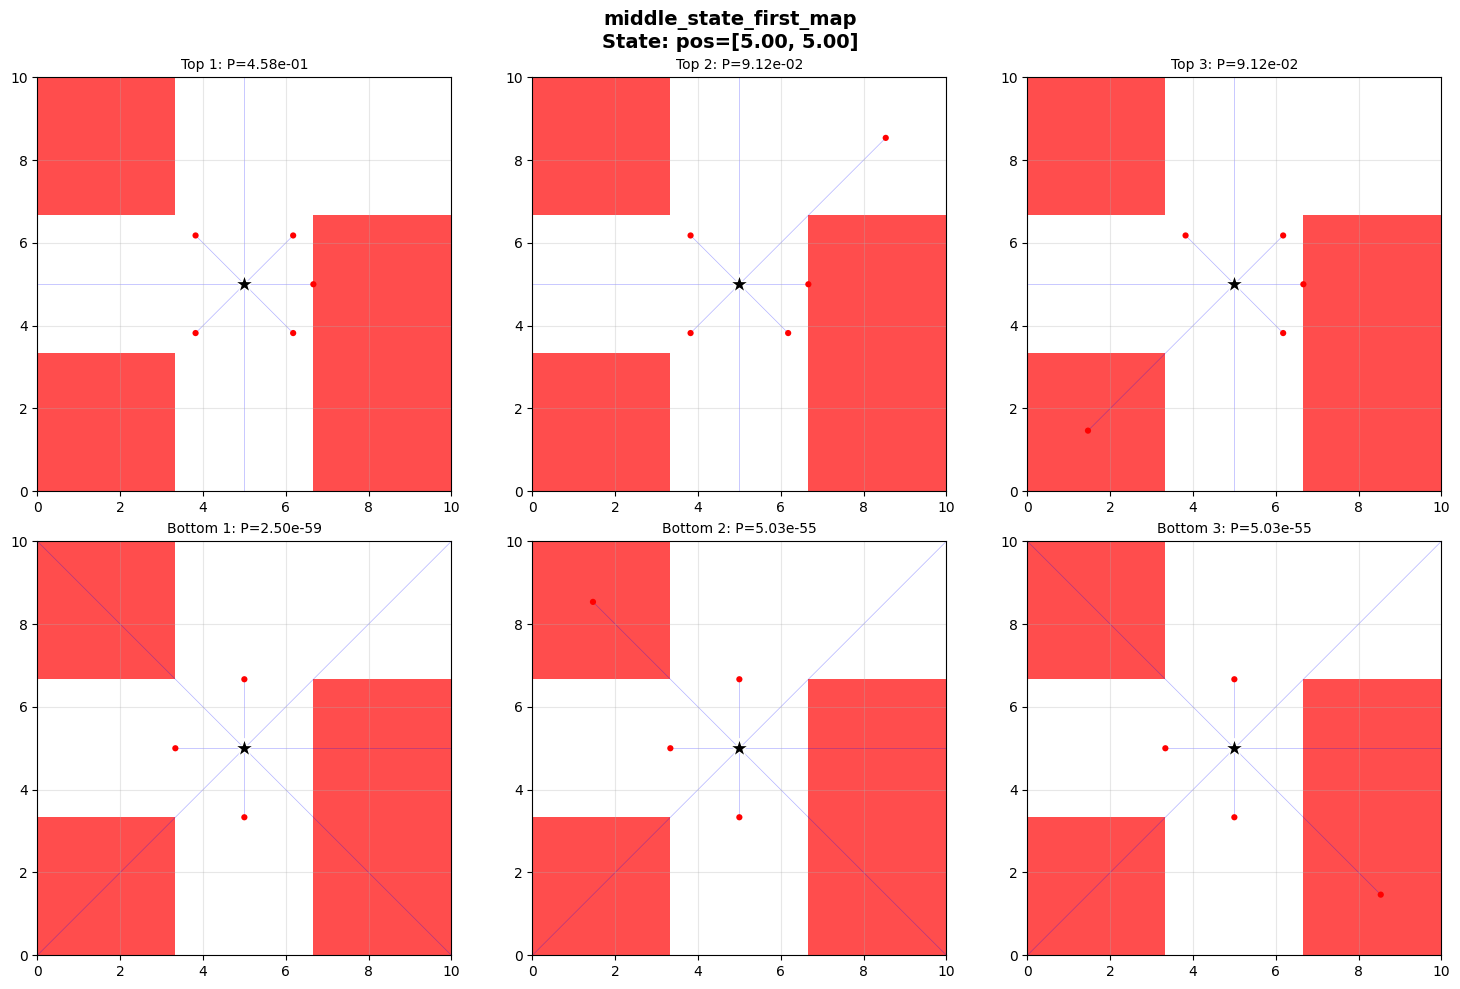

Saved figure to /global/home/hpc5656/SLAM/notebooks/slam/outputs/qmat_visuals/measurements_middle_state_first_map.png


In [12]:
# Visualize top 3 and bottom 3 probability measurements as LIDAR rays
print('\n=== Visualizing Top and Bottom Probability Measurements ===\n')

# Use the same state-map pairs as before
i_state = mdp.SQ.m_n // 2
j_map = 101

visualize_measurements(mdp, i_state, j_map, title='middle_state_first_map', n_top=3, n_bottom=3)

In [7]:
# Analyze Q_n statistics
print('\n=== Q_n Statistics ===\n')

Q_n = mdp.Q_n
m_y, m_n, len_M = Q_n.shape

print(f'Q_n shape: ({m_y}, {m_n}, {len_M})')
print(f'Total elements: {Q_n.size:,}')
print(f'\nValue statistics:')
print(f'  Min: {np.min(Q_n):.6e}')
print(f'  Max: {np.max(Q_n):.6e}')
print(f'  Mean: {np.mean(Q_n):.6e}')
print(f'  Median: {np.median(Q_n):.6e}')
print(f'  Std: {np.std(Q_n):.6e}')

# Count zeros and near-zeros
zero_count = np.sum(Q_n == 0.0)
near_zero_count = np.sum(Q_n < 1e-10)
print(f'\nSparsity:')
print(f'  Exact zeros: {zero_count:,} ({zero_count/Q_n.size*100:.2f}%)')
print(f'  Near-zeros (<1e-10): {near_zero_count:,} ({near_zero_count/Q_n.size*100:.2f}%)')

# Entropy analysis (for each state-map pair)
entropies = []
for i in range(m_n):
    for j in range(len_M):
        dist = Q_n[:, i, j]
        # Avoid log(0)
        dist_safe = np.maximum(dist, 1e-300)
        entropy = -np.sum(dist * np.log(dist_safe))
        entropies.append(entropy)

entropies = np.array(entropies)
print(f'\nEntropy statistics (over state-map pairs):')
print(f'  Min entropy: {np.min(entropies):.6f}')
print(f'  Max entropy: {np.max(entropies):.6f}')
print(f'  Mean entropy: {np.mean(entropies):.6f}')
print(f'  Max possible entropy (log(m_y)): {np.log(m_y):.6f}')


=== Q_n Statistics ===

Q_n shape: (6561, 81, 512)
Total elements: 272,097,792

Value statistics:
  Min: 2.198590e-85
  Max: 9.931556e-01
  Mean: 1.524158e-04
  Median: 1.421696e-19
  Std: 6.019067e-03

Sparsity:
  Exact zeros: 0 (0.00%)
  Near-zeros (<1e-10): 232,476,075 (85.44%)

Entropy statistics (over state-map pairs):
  Min entropy: 0.055334
  Max entropy: 4.102910
  Mean entropy: 2.384881
  Max possible entropy (log(m_y)): 8.788898


In [ ]:
# Performance test: Compare Q_n computation time
import time

print('\n=== Q_n Computation Performance ===\n')

# Test with different sizes
# Test with different sizes
# Note: n=4 is skipped as it requires computing T_mat which is extremely slow
# (state space grows exponentially with n)
test_configs = [
    (2, 2, 1.0),  # Small
    (3, 3, 1.0),  # Medium
    # (4, 3, 1.0),  # Larger - skipped: T_mat computation too slow
]

for n, obs_n, sigma_v in test_configs:
    print(f'\nTesting n={n}, obs_n={obs_n}, sigma_v={sigma_v}...')
    
    # Clear cache to force recomputation
    test_mdp_temp = build_mdp(n=n, obs_n=obs_n, dt=1, max_a=2.0, sigma_v=sigma_v)
    cache_path = test_mdp_temp._get_Q_cache_path()
    if cache_path.exists():
        cache_path.unlink()
    
    start_time = time.time()
    test_mdp = build_mdp(n=n, obs_n=obs_n, dt=1, max_a=2.0, sigma_v=sigma_v)
    elapsed = time.time() - start_time
    
    m_y, m_n, len_M = test_mdp.Q_n.shape
    total_elements = test_mdp.Q_n.size
    
    print(f'  Q_n shape: ({m_y}, {m_n}, {len_M})')
    print(f'  Total elements: {total_elements:,}')
    print(f'  Computation time: {elapsed:.2f}s')
    print(f'  Time per element: {elapsed/total_elements*1e6:.4f} μs')
    
    # Verify properties
    results = verify_stochastic_properties(test_mdp.Q_n)
    print(f'  ✓ Stochastic properties valid: {results["row_sums_valid"]}')


=== Q_n Computation Performance ===


Testing n=2, obs_n=2, sigma_v=1.0...
Loaded cached T_mat from /global/home/hpc5656/SLAM/cache/T_mat/T_mat_n2_map2x2_max2.0_ea380e8a.npz
  Checking cache file: Q_n_n2_obs2_map2x2_B8_02c1e09a.npz
  ✓ Cache metadata matches, loading Q_n
Loaded cached Q_n from /global/home/hpc5656/SLAM/cache/Q_n/Q_n_n2_obs2_map2x2_B8_02c1e09a.npz
  Checking cache file: Q_n_n2_obs2_map2x2_B8_02c1e09a.npz
  ✓ Cache metadata matches, loading Q_n
Loaded cached Q_n with obs_n=2 from /global/home/hpc5656/SLAM/cache/Q_n/Q_n_n2_obs2_map2x2_B8_02c1e09a.npz


Computing Q_n:   0%|          | 0/256 [00:00<?, ?it/s]

  Q_n shape: (256, 16, 16)
  Total elements: 65,536
  Computation time: 0.07s
  Time per element: 1.0607 μs
  ✓ Stochastic properties valid: True

Testing n=3, obs_n=3, sigma_v=1.0...
Loaded cached T_mat from /global/home/hpc5656/SLAM/cache/T_mat/T_mat_n3_map3x3_max2.0_c2818dab.npz
  Cache file does not exist: /global/home/hpc5656/SLAM/cache/Q_n/Q_n_n3_obs3_map3x3_B8_c18e598c.npz
Computing Q_n for the first time...


Computing Q_n:   0%|          | 0/6561 [00:00<?, ?it/s]

Saved Q_n to /global/home/hpc5656/SLAM/cache/Q_n/Q_n_n3_obs3_map3x3_B8_c18e598c.npz
  Checking cache file: Q_n_n3_obs3_map3x3_B8_c18e598c.npz
  ✓ Cache metadata matches, loading Q_n
Loaded cached Q_n with obs_n=3 from /global/home/hpc5656/SLAM/cache/Q_n/Q_n_n3_obs3_map3x3_B8_c18e598c.npz


Computing Q_n:   0%|          | 0/6561 [00:00<?, ?it/s]

  Q_n shape: (6561, 81, 512)
  Total elements: 272,097,792
  Computation time: 122.79s
  Time per element: 0.4513 μs
  ✓ Stochastic properties valid: True
